# Principal Component Analysis (Dimensionality Reduction.)


## What is Dimensionality?
Suppose our dataset has:

    Student
    │
    ├── Study Hours
    ├── Previous Marks
    ├── Attendance
    ├── Assignments
    ├── Sleep Hours
    ├── Mock Test Score
    └── Final Marks
We have several columns/features. \
Each feature is a dimension.

So: \
2 features → 2 dimensions \
5 features → 5 dimensions \
20 features → 20 dimensions \
100 features → 100 dimensions

## Why Reduce Dimensions?

Imagine a dataset with: 100 features \
Some features may contain very similar information.

For example: \
Math Marks \
Physics Marks \
Chemistry Marks \
Science Marks

These may all be related to a student's academic performance. \
Keeping all of them can sometimes make the dataset unnecessarily complicated. \
PCA attempts to transform many correlated features into a smaller number of new features called **principal components**.

## What Does PCA Do?

Suppose we have: 10 features \
PCA might transform them into:
PC1 \
PC2 \
PC3

So:

    10 original features
        ↓
       PCA
        ↓
    3 principal components
We reduced: 10 dimensions → 3 dimensions \
while trying to preserve as much important variation in the data as possible.

## What is a Principal Component?
A principal component is a new feature created by combining information from the original features.

For example:

Original: \
Hours \
Marks \
Attendance

PCA may create: \
PC1 \
PC2

These aren't directly "Hours" or "Marks". \
Instead, they are mathematical combinations of the original variables. \
Think:

    Hours ──────┐
    Marks ──────┼──→ PC1
    Attendance ─┘

    Hours ──────┐
    Marks ──────┼──→ PC2
    Attendance ─┘
    
## Variance
This is the key idea behind PCA. \
Variance tells us how much the data varies.

Suppose:

Feature A: \
50 \
51 \
50 \
51 \
50

Very little variation. \
Another feature:

Feature B: \
10 \
30 \
50 \
70 \
90

Much more variation. \
PCA looks for directions in the data that contain large amounts of variation.

### First Principal Component

PCA finds the direction with the largest variance. \
That becomes: PC1

Then it finds another direction containing the next largest amount of variance: PC2

Then: PC3 \
and so on.

Conceptually:

    Data
     ↓
    Largest variance
     ↓
    PC1

    Remaining variance
     ↓
    PC2

    Remaining variance
     ↓
    PC3
    
#### Explained Variance
This is one of the most important PCA concepts.

Suppose: \
PC1 → 70% \
PC2 → 20% \
PC3 → 7% \
PC4 → 3%

Then: \
PC1 + PC2 \
= 70% + 20% \
= 90%

So just two components preserve 90% of the variance. \
That means we might reduce: 4 dimensions → 2 dimensions \
while retaining 90% of the variance.

## Example

In [1]:
import pandas as pd
data = {
    "Math": [80, 85, 90, 70, 75],
    "Physics": [78, 88, 92, 68, 73],
    "Chemistry": [82, 84, 89, 72, 76]
}

df = pd.DataFrame(data)
print(df)

   Math  Physics  Chemistry
0    80       78         82
1    85       88         84
2    90       92         89
3    70       68         72
4    75       73         76


We have: 3 features \
We can attempt to reduce them to: 2 components

In [2]:
from sklearn.decomposition import PCA

In [3]:
X = df[["Math","Physics","Chemistry"]]

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Why? \
Because features can have different scales.

For example: \
Age: 18–60

Salary: 20,000–200,000

Experience: 0–30

Salary has much larger numerical values. \
Without proper scaling, features with larger scales can influence PCA disproportionately. \
Therefore, PCA is commonly applied after standardization.

### What Does StandardScaler Do?

Conceptually, it transforms the features so they are centered around: mean = 0

with approximately: standard deviation = 1

    Raw Data
       ↓
    StandardScaler
       ↓
    Scaled Data
       ↓
      PCA

In [5]:
#Create PCA
pca = PCA(n_components=2)

This means: Keep 2 principal components.

Originally: \
Math \
Physics \
Chemistry

After PCA: \
PC1 \
PC2

In [7]:
#Transform
X_pca = pca.fit_transform(X_scaled)

This is the important PCA operation.

It does two things:

    fit
    ↓
    learn the principal components

and:

    transform
    ↓
    convert the original data into the new component space

So:

    X_scaled
       ↓
      PCA
       ↓
      X_pca

In [8]:
print(X_pca)

[[ 0.01954918 -0.30611701]
 [ 1.26212787  0.24413565]
 [ 2.40951128 -0.03340597]
 [-2.40316492  0.08859225]
 [-1.2880234   0.00679508]]


In [9]:
#Convert PCA Result into DataFrame

pca_df = pd.DataFrame(
    X_pca, columns=["PC1","PC2"]
)

print(pca_df)

        PC1       PC2
0  0.019549 -0.306117
1  1.262128  0.244136
2  2.409511 -0.033406
3 -2.403165  0.088592
4 -1.288023  0.006795


In [13]:
# How much information does each component retain?
print(pca.explained_variance_ratio_)

[0.98888663 0.01082137]


PC1 → 98% \
PC2 → 1%

Together 99% of the variance is retained.

In [12]:
# Total Explained Variance

total_variance = (
    pca.explained_variance_ratio_.sum()
)

print(
    f"Total explained variance: "
    f"{total_variance * 100:.2f}%"
)

Total explained variance: 99.97%


## PCA + Logistic Regression

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [15]:
data = {
    "Math": [40, 45, 50, 55, 60,
             65, 70, 75, 80, 90],
    "Physics": [42, 44, 51, 56, 61,
                64, 71, 74, 82, 88],
    "Chemistry": [38, 46, 49, 57, 59,
                  66, 69, 77, 79, 91],
    "Pass": [0, 0, 0, 1, 1,
             1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

In [16]:
X = df[["Math", "Physics", "Chemistry"]]

y = df["Pass"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [21]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

In [22]:
pca.fit_transform(X_train_scaled)

array([[ 0.20422721,  0.08896904],
       [-2.78060861, -0.04048652],
       [ 1.44216286,  0.07617274],
       [-1.58558386, -0.00784966],
       [ 3.16250857, -0.02332273],
       [-0.38510696, -0.07093964],
       [-0.87296915,  0.11148637],
       [ 0.81536994, -0.13402961]])

In [24]:
pca.transform(X_test_scaled)

array([[ 2.05875772, -0.24255275],
       [-2.19672658,  0.21514899]])

In [25]:
model = LogisticRegression()

model.fit(
    X_train_pca,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
predictions = model.predict(
    X_test_pca
)

In [28]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 100.00%


pipeline is:

    Original Features
       ↓
    StandardScaler
       ↓
      PCA
       ↓
    Logistic Regression
       ↓
    Prediction
    
## PCA Is Unsupervised

This is important. \
PCA does not use the target variable.

For example:

X: \
Math \
Physics \
Chemistry

PCA looks only at X.

It doesn't care whether: \
Pass = 0 \
Pass = 1

So PCA is considered an unsupervised dimensionality-reduction technique.

## PCA and Target Variable

In [31]:
X = df[
    [
        "Math",
        "Physics",
        "Chemistry"
    ]
]

y = df["Pass"]

In [32]:
pca.fit_transform(X)

array([[-40.1212139 ,   1.71663523],
       [-31.36037709,  -2.31363297],
       [-22.7714716 ,   0.72350997],
       [-12.33300579,  -1.17033511],
       [ -5.45611557,   1.14386694],
       [  3.27033498,  -1.47291903],
       [ 11.85924047,   1.56422391],
       [ 21.17928694,  -1.75390324],
       [ 29.73380617,   2.69672192],
       [ 45.99951539,  -1.13416764]])

## PCA + Scatter Plot

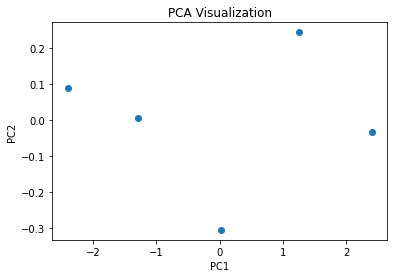

In [33]:
import matplotlib.pyplot as plt

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("PCA Visualization")

plt.show()

In [34]:
X_pca[:, 0]

array([ 0.01954918,  1.26212787,  2.40951128, -2.40316492, -1.2880234 ])